# Прогнозирование цены

### Задача
Целевая переменная — `price`. У вас есть 4 атрибута, и, очевидно, мы хотим, чтобы вы построили некую модель машинного обучения, которая прогнозирует цены.

1. Проведите первоначальный анализ данных.
2. Используйте ML модель и кратко объясните свой выбор.
3. Покажите точность вашей модели и прокомментируйте результаты.
4. Представьте нам результаты и шаги, которые вы предприняли, а также некоторые критические размышления.
5. Визуализируйте на графиках точность модели, важность признаков и корреляцию признаков с ценой.  

### Описание данных
Данные представлены в файле `price_sample.csv`.

### Комментарии

Определите, обучите и оцените прогнозирующую модель, которая принимает в качестве входных данных предоставленные данные. По вашему усмотрению вы можете разделить данные на наборы для обучения, тестирования. 

Убедитесь, что решение отражает весь ваш мыслительный процесс (для каждой ячейки кода оставляйте комментарии, иначе мы не поймем, что вы хотели сделать)

### Что мы точно хотим увидеть в вашей работе?

1. **Анализ данных**: Проведение первичного анализа данных для понимания их структуры и основных характеристик. 

2. **Обработка данных**: Это критически важный шаг, который включает в себя очистку данных, обработку пропущенных значений и дубликатов.

3. **Оценка модели**: Обучение и тестирование подходящей модели и оценка ее производительности с использованием релевантных метрик.

4. **Визуализация**: Постройте графики, которые покажут точность модели, важность признаков и корреляцию признаков с ценой. 

In [5]:
#Анализ данных
import pandas as pd 

df = pd.read_csv("price_sample.csv")
print(df.head())
print(df.shape)
print(df.info)
print(df.isnull().sum())
print(df.describe())

   para1  para2    para3  para4   price
0      1  662.0   3000.0    3.8   73.49
1      1  340.0   2760.0    9.2  300.00
2      0   16.0   2700.0    3.0  130.00
3      1   17.0  12320.0    6.4  365.00
4      1  610.0   2117.0   10.8  357.50
(10003, 5)
<bound method DataFrame.info of        para1  para2    para3  para4   price
0          1  662.0   3000.0    3.8   73.49
1          1  340.0   2760.0    9.2  300.00
2          0   16.0   2700.0    3.0  130.00
3          1   17.0  12320.0    6.4  365.00
4          1  610.0   2117.0   10.8  357.50
...      ...    ...      ...    ...     ...
9998       3  386.0   5000.0   12.0  460.00
9999       1  386.0   3250.0    8.0  325.00
10000      0  190.0   8856.0    5.6  133.33
10001      3  717.0   5000.0   13.6  820.00
10002      1  622.0    336.0    4.8  375.00

[10003 rows x 5 columns]>
para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64
              para1        para2         para3        para4         price
count  10003.000000 

In [11]:
#Обработка данных
df = df.drop_duplicates()
df.fillna({"para4":df["para4"].mean()}, inplace = True)  #Заменяю все null значения в "para4" на среднюю, потому что там небольшое отклонение от среднего
df.dropna(subset = ["para2"], inplace = True) #Удаляю все null значения в "para6", так как там их немного и отклонение от среднего слишком большое 
print(df.isnull().sum())
print(df.shape)

para1    0
para2    0
para3    0
para4    0
price    0
dtype: int64
(9782, 5)


In [13]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = "price")
y = df["price"] #Отделаю признаки "Х" от таргет "y" 

#Разделяю данные на тренировочные и тестовые в пропорции 70 к 30 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42) 

print(X_train.shape)
print(X_test.shape)

(6847, 4)
(2935, 4)


In [14]:
#Оценка модели
#Выбираю RandomForestRegressor так как данные табличные, возможна нелинейная зависимость и не требует масштабирования
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(n_estimators = 300, random_state = 42)
model.fit(X_train, y_train)  #Обучаю модель на тренировочных данных
y_pred = model.predict(X_test) #Делаю предсказания на тестовых данных

#Оцениваю качество модели
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}") # ~96, модель ошибается примерно на 96 единиц, сред. значение цены ~434, модель ошибается примерно на 22% это средний результат
print(f"MSE: {mse}") # root(mse) ~ 152, это ощутимая ошибка, значит в данных возможно есть outliers, 
print(f"R2: {r2}") #r^2 ~70%, Модель объясняет 70% вариации цены, это относительно хороший результат

MAE: 95.89593819632604
MSE: 23206.042700849317
R2: 0.6993509763283552


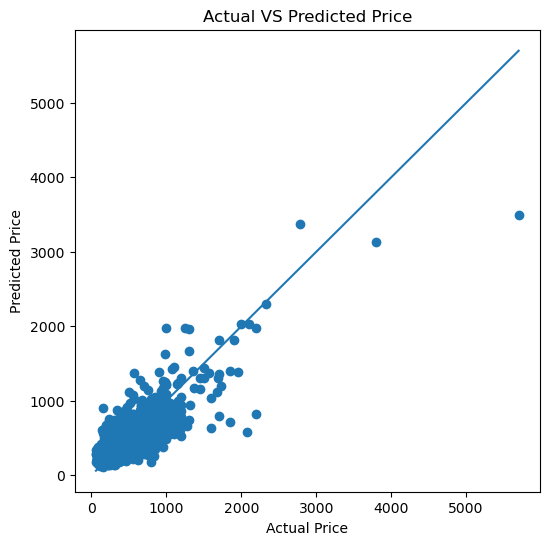

In [16]:
#Визуализация: точность модели
import matplotlib.pyplot as plt 

plt.figure(figsize = (6,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual VS Predicted Price")

#Добавляю линию предсказания
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show() # Модель хорошо работает на основной массе данных, но плохо работает на дорогом сегменте

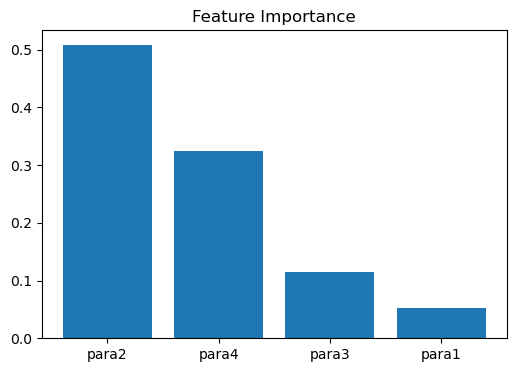

In [18]:
#Визуализация: важность признаков и корреляцию признаков с ценой

#Получаю важность признаков из модели
importance = pd.Series(model.feature_importances_, index = X.columns).sort_values(ascending = False)

plt.figure(figsize = (6,4))
plt.bar(importance.index, importance.values)
plt.title("Feature Importance")
plt.show() #para2 - самый важный признак, а para1 почти не коррелирует с price

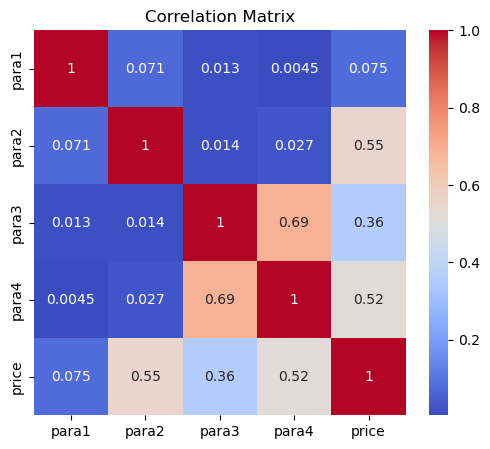

price    1.000000
para2    0.551714
para4    0.518228
para3    0.358425
para1    0.075281
Name: price, dtype: float64


In [21]:
#Визуализация: корреляция признаков с ценой
import seaborn as sns 

#Составляю матрицу корреляции
correlation = df.corr()

plt.figure(figsize = (6,5))
sns.heatmap(correlation, annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

#Вывожу корреляцию каждого признака с ценой
print(correlation["price"].sort_values(ascending = False))